
# 🎵 Análisis y Visualización de Datos de Spotify

Exploramos las características de audio de 2000 canciones populares entre 1998 y 2020.

[Top Hits Spotify from 2000-2019](https://www.kaggle.com/datasets/paradisejoy/top-hits-spotify-from-20002019)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from plotly.offline import iplot
from plotly.subplots import make_subplots
import seaborn as sns

# Configuración para gráficos más bonitos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Lectura de datos e información inicial

Cargamos el dataset `songs_normalize.csv` que contiene 2000 canciones con 18 columnas.

In [3]:
df = pd.read_csv('/content/songs_normalize.csv')

# Muestra aleatoria de 5 canciones
df.sample(5)

,artist,song,duration_ms,explicit,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
51,Ricky Martin,She Bangs - English Version,280626,False,2000,60,0.630,0.950,1,-4.012,1,0.0806,0.000915,0.000007,0.373,0.858,143.866,"pop, latin"
1746,Lil Pump,Gucci Gang,124055,True,2017,64,0.936,0.523,5,-6.710,1,0.0597,0.239000,0.000000,0.117,0.699,119.889,hip hop
1208,Rihanna,Where Have You Been,242680,False,2011,71,0.719,0.847,0,-6.340,0,0.0916,0.002010,0.020400,0.223,0.444,127.963,"hip hop, pop, R&B"
846,Natasha Bedingfield,Pocketful of Sunshine,203440,False,2008,62,0.726,0.881,9,-3.892,0,0.0391,0.203000,0.000000,0.108,0.682,110.019,pop
1993,Joel Corry,Sorry,188640,False,2019,63,0.744,0.790,8,-4.617,0,0.0562,0.054700,0.000802,0.320,0.847,125.002,"pop, Dance/Electronic"


In [5]:
#Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist            2000 non-null   object 
 1   song              2000 non-null   object 
 2   duration_ms       2000 non-null   int64  
 3   explicit          2000 non-null   bool   
 4   year              2000 non-null   int64  
 5   popularity        2000 non-null   int64  
 6   danceability      2000 non-null   float64
 7   energy            2000 non-null   float64
 8   key               2000 non-null   int64  
 9   loudness          2000 non-null   float64
 10  mode              2000 non-null   int64  
 11  speechiness       2000 non-null   float64
 12  acousticness      2000 non-null   float64
 13  instrumentalness  2000 non-null   float64
 14  liveness          2000 non-null   float64
 15  valence           2000 non-null   float64
 16  tempo             2000 non-null   float64


In [6]:
df.describe()

,duration_ms,year,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,228748.124500,2009.49400,59.872500,0.667438,0.720366,5.378000,-5.512434,0.553500,0.103568,0.128955,0.015226,0.181216,0.551690,120.122558
std,39136.569008,5.85996,21.335577,0.140416,0.152745,3.615059,1.933482,0.497254,0.096159,0.173346,0.087771,0.140669,0.220864,26.967112
min,113000.000000,1998.00000,0.000000,0.129000,0.054900,0.000000,-20.514000,0.000000,0.023200,0.000019,0.000000,0.021500,0.038100,60.019000
25%,203580.000000,2004.00000,56.000000,0.581000,0.622000,2.000000,-6.490250,0.000000,0.039600,0.014000,0.000000,0.088100,0.386750,98.985750
50%,223279.500000,2010.00000,65.500000,0.676000,0.736000,6.000000,-5.285000,1.000000,0.059850,0.055700,0.000000,0.124000,0.557500,120.021500
75%,248133.000000,2015.00000,73.000000,0.764000,0.839000,8.000000,-4.167750,1.000000,0.129000,0.176250,0.000068,0.241000,0.730000,134.265500
max,484146.000000,2020.00000,89.000000,0.975000,0.999000,11.000000,-0.276000,1.000000,0.576000,0.976000,0.985000,0.853000,0.973000,210.851000


# 3. Significado de cada característica

artist: Nombre del artista.

song: Título de la canción.

duration_ms: Duración en milisegundos.

explicit: Si la letra es explícita (True/False).

year: Año de lanzamiento.

popularity: Puntuación de popularidad (0-100).

danceability: Idoneidad para bailar (0-1).

energy: Intensidad y actividad percibida (0-1).

key: Tonalidad (0=C, 1=C#/Db, ... 11=B).

loudness: Sonoridad en decibelios (dB).

mode: Modo mayor (1) o menor (0).

speechiness: Presencia de palabras habladas (0-1).

acousticness: Confianza de que la pista es acústica (0-1).

instrumentalness: Probabilidad de que no tenga voz (0-1).

liveness: Presencia de audiencia en vivo (0-1).

valence: Positividad musical (0-1; alto = feliz).

tempo: Ritmo en pulsaciones por minuto (BPM).

genre: Género musical.



# 4. Distribución de canciones por año



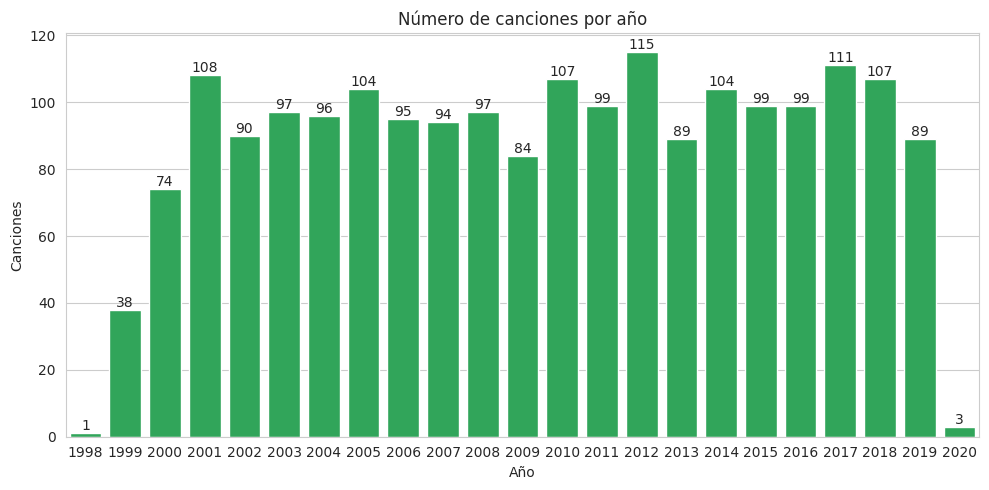

In [10]:
# Contar canciones por año
songs_per_years = df['year'].value_counts().sort_index()

# Crear figura
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=songs_per_years.index.astype(str),
    y=songs_per_years.values,
    color='#1DB954'
)

# Agregar etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Títulos y etiquetas
ax.set_title('Número de canciones por año')
ax.set_xlabel('Año')
ax.set_ylabel('Canciones')

plt.tight_layout()
plt.show()


Observación: Este dataset fue curado para mostrar la mayor parte de canciones entre los años 1998 y 2020. Claramente, no son todas las canciones.


#5. Análisis de artistas
##5.1 Número total de artistas y top 10

In [11]:
print(f"Hay un total de {df['artist'].nunique()} artistas en el dataset.")

artists = df['artist'].value_counts()
artists.head(10)

Hay un total de 835 artistas en el dataset.


,count
artist,
Rihanna,25
Drake,23
Eminem,21
Calvin Harris,20
Britney Spears,19
David Guetta,18
Chris Brown,17
Kanye West,17
Katy Perry,16


## 5.2 Participación de los 40 artistas principales

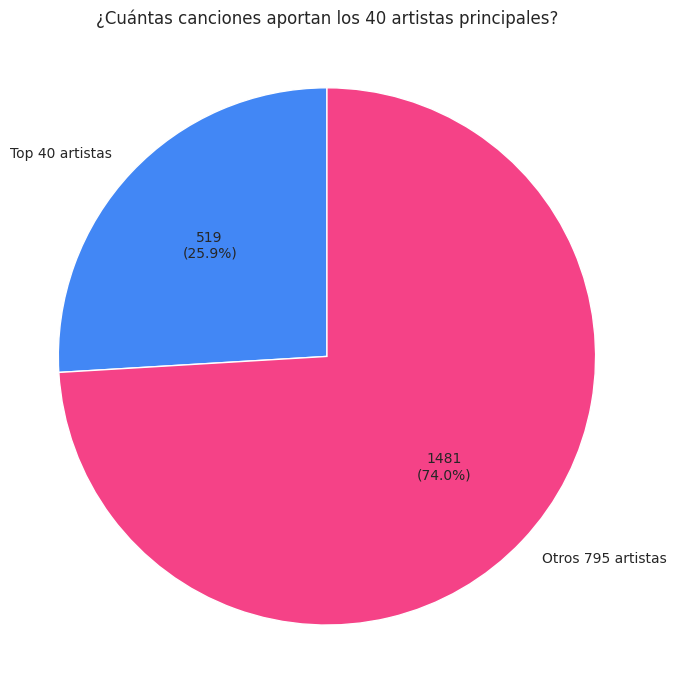

In [13]:
top40_sum = artists[:40].sum()
other_sum = 2000 - top40_sum


values = [top40_sum, other_sum]
labels = [
    'Top 40 artistas',
    f'Otros {df["artist"].nunique() - 40} artistas'
]

def format_label(pct):
    total = sum(values)
    value = int(round(pct * total / 100))
    return f'{value}\n({pct:.1f}%)'

plt.figure(figsize=(7, 7))

plt.pie(
    values,
    labels=labels,
    colors=['#4287f5', '#f54287'],
    autopct=format_label,
    startangle=90
)

plt.title('¿Cuántas canciones aportan los 40 artistas principales?')
plt.axis('equal')

plt.tight_layout()
plt.show()

Los 40 artistas principales concentran el 26% de las canciones del dataset.

## 5.3 Popularidad promedio por artista (top 10)

In [24]:
artist_pop = df.groupby('artist')['popularity'].mean().sort_values(ascending=False)
artist_count = df['artist'].value_counts()

artist_df = pd.DataFrame({
    'popularity': artist_pop,
    'total_songs': artist_count
}).reset_index()

artist_df.columns = ['artist', 'avg_popularity', 'total_songs']

artist_df = artist_df.sort_values(by='total_songs',ascending=False)



artist_df.head(10)

,artist,avg_popularity,total_songs
628,Rihanna,72.120000,25
219,Drake,61.913043,23
239,Eminem,72.333333,21
127,Calvin Harris,67.800000,20
118,Britney Spears,63.052632,19
196,David Guetta,65.833333,18
156,Chris Brown,63.529412,17
387,Kanye West,61.705882,17
391,Katy Perry,64.562500,16
719,Taylor Swift,70.312500,16


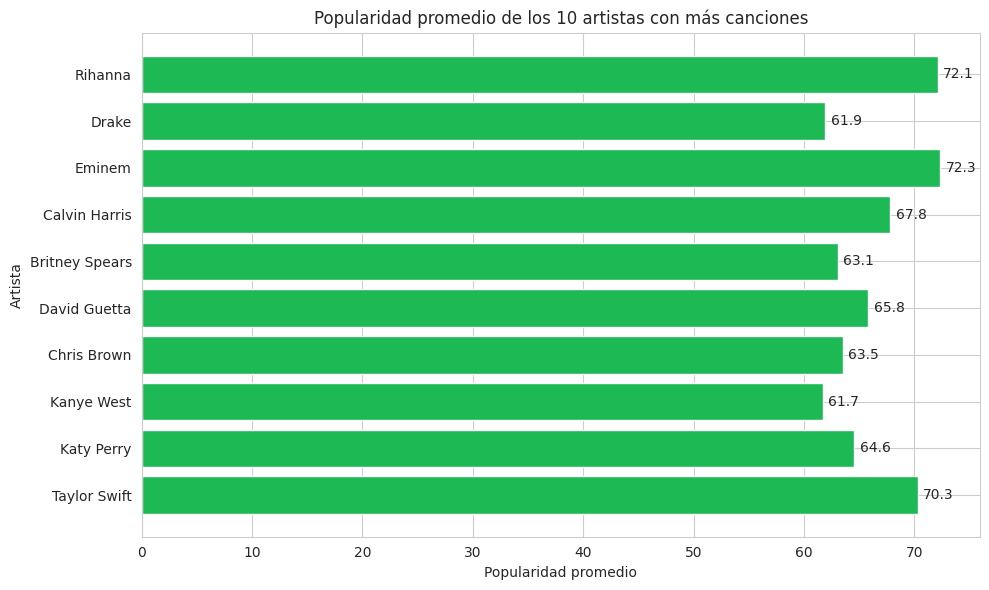

In [25]:
top10 = artist_df.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top10['artist'],
    top10['avg_popularity'],
    color='#1DB954'
)

# Mostrar valores
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.1f}',
        va='center'
    )

plt.title('Popularidad promedio de los 10 artistas con más canciones')
plt.xlabel('Popularidad promedio')
plt.ylabel('Artista')

# Para que el primero aparezca arriba
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

# 6. Evolución temporal de la duración de las canciones

In [28]:
def ms_to_minsec(ms):
    sec = ms / 1000
    return f"{int(sec // 60)}:{int(sec % 60):02d}"

# Excluimos 1998 y 2020 por pocas muestras
durations = df[['duration_ms', 'year']].groupby('year').mean().reset_index().iloc[1:-1]
durations['duration_s'] = durations['duration_ms'] / 1000
durations['min:sec'] = durations['duration_ms'].apply(ms_to_minsec)

durations['year'] = durations['year'].astype(str)

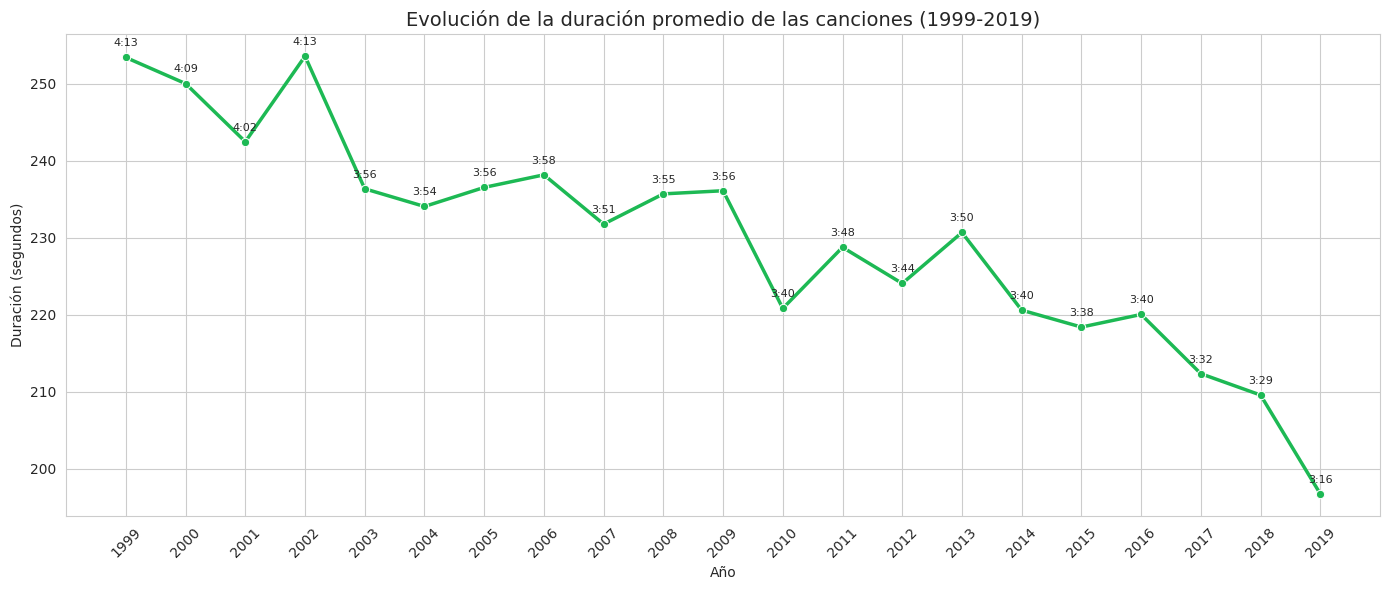

In [29]:
plt.figure(figsize=(14, 6))


ax = sns.lineplot(
    data=durations,
    x='year',
    y='duration_s',
    marker='o',
    linewidth=2.5,
    color='#1DB954'
)

for _, row in durations.iterrows():
    ax.annotate(
        row['min:sec'],
        (row['year'], row['duration_s']),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8
    )

ax.set_title(
    'Evolución de la duración promedio de las canciones (1999-2019)',
    fontsize=14
)
ax.set_xlabel('Año')
ax.set_ylabel('Duración (segundos)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observación: Se aprecia una tendencia a la reducción de la duración media, pasando de ~4:13 en 1999 a ~3:16 en 2019. Esto confirma la tendencia a canciones más cortas en la era del streaming.

#7. Canción más larga y más corta



In [30]:
df['min:sec'] = df['duration_ms'].apply(ms_to_minsec)

longest = df[df['duration_ms'] == df['duration_ms'].max()]
shortest = df[df['duration_ms'] == df['duration_ms'].min()]

print("Canción más larga:")
display(longest[['artist', 'song', 'min:sec', 'year']])

print("Canción más corta:")
display(shortest[['artist', 'song', 'min:sec', 'year']])

Canción más larga:


,artist,song,min:sec,year
1381,Justin Timberlake,Mirrors,8:04,2013


Canción más corta:


,artist,song,min:sec,year
1931,Lil Nas X,Old Town Road,1:53,2019


# 8. Evolución de canciones explícitas vs. no explícitas

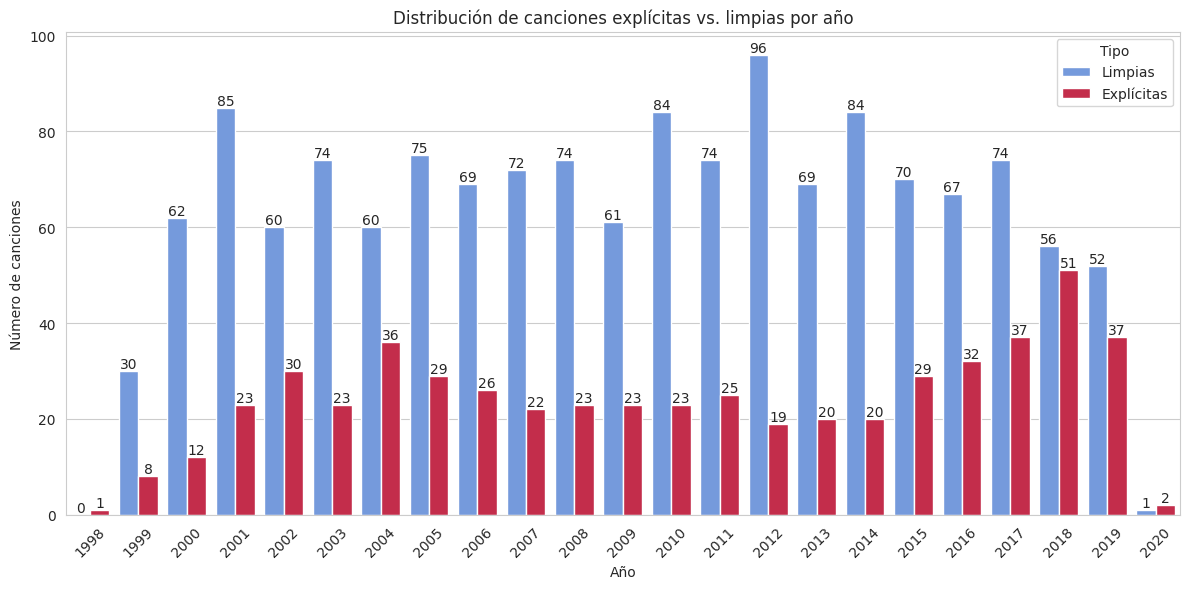

In [31]:
# Agrupar datos
year_explicit = (
    df.groupby(['year', 'explicit'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

year_explicit.rename(
    columns={False: 'Limpias', True: 'Explícitas'},
    inplace=True
)

# Convertir a formato largo para Seaborn
year_explicit_long = year_explicit.melt(
    id_vars='year',
    value_vars=['Limpias', 'Explícitas'],
    var_name='Tipo',
    value_name='Número de canciones'
)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=year_explicit_long,
    x='year',
    y='Número de canciones',
    hue='Tipo',
    palette=['cornflowerblue', 'crimson']
)

# Mostrar valores sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

ax.set_title('Distribución de canciones explícitas vs. limpias por año')
ax.set_xlabel('Año')
ax.set_ylabel('Número de canciones')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Observamos que a partir de 2015 las canciones explícitas empiezan a subir, reflejando un cambio en la industria hacia una mayor libertad de contenido.

#9. Modo mayor vs. menor por tonalidad

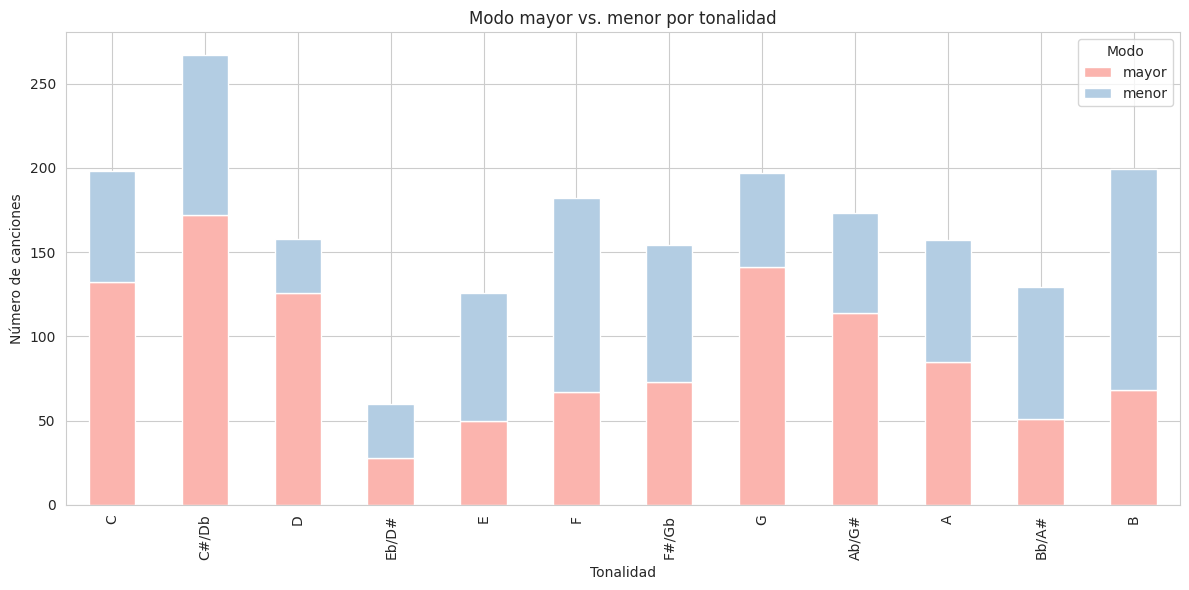

In [39]:
key_mode = df.groupby(['key','mode']).size().unstack(fill_value=0).reset_index()
key_names = ['C', 'C#/Db', 'D', 'Eb/D#', 'E', 'F', 'F#/Gb', 'G', 'Ab/G#', 'A', 'Bb/A#', 'B']
key_mode.rename(columns={0:'menor', 1:'mayor'}, inplace=True)
key_mode['tonalidad'] = key_names

key_mode.set_index('tonalidad')[['mayor', 'menor']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=sns.color_palette('Pastel1')
)

plt.title('Modo mayor vs. menor por tonalidad')
plt.xlabel('Tonalidad')
plt.ylabel('Número de canciones')
plt.legend(title='Modo')

plt.tight_layout()
plt.show()

Observación: La tonalidad de Do (C) y Sol (G) son las más frecuentes, y el modo mayor predomina en casi todas las tonalidades, excepto en Fa (F) donde el menor es más común.

#10. Distribuciones de las características de audio

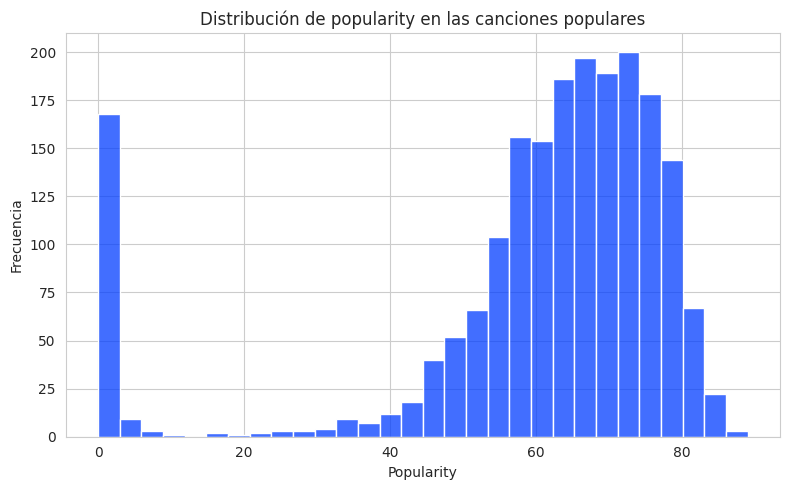

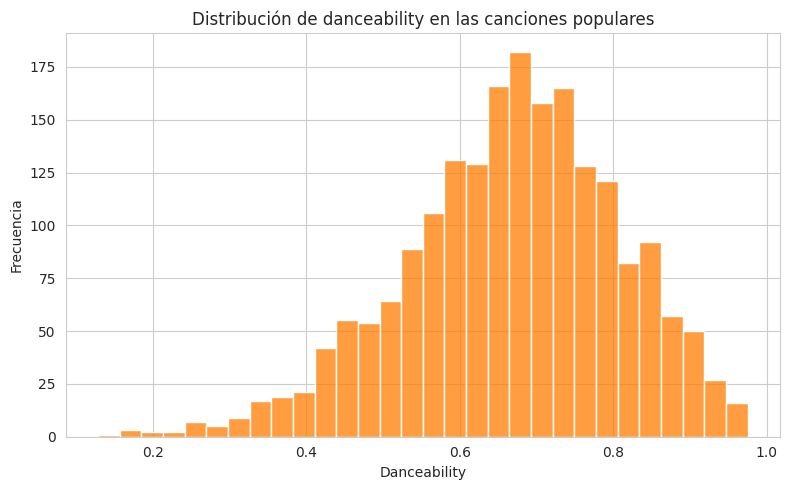

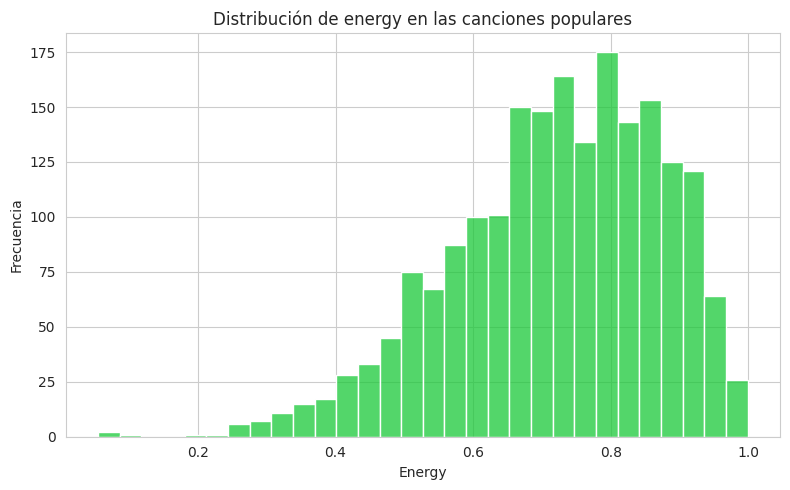

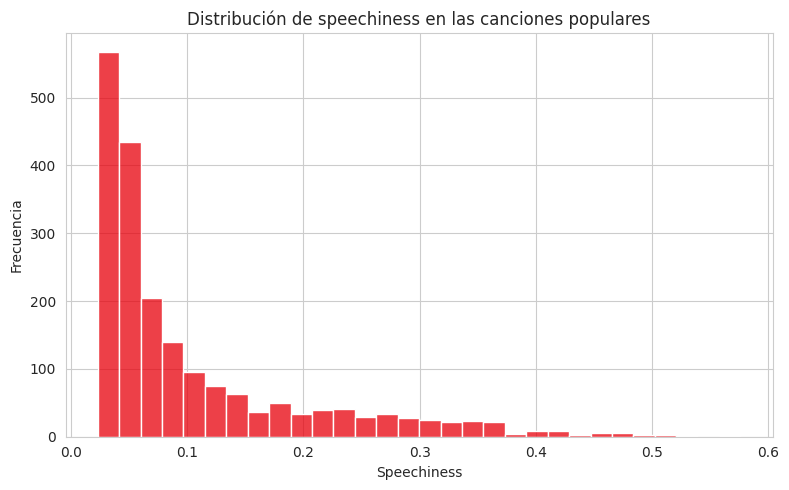

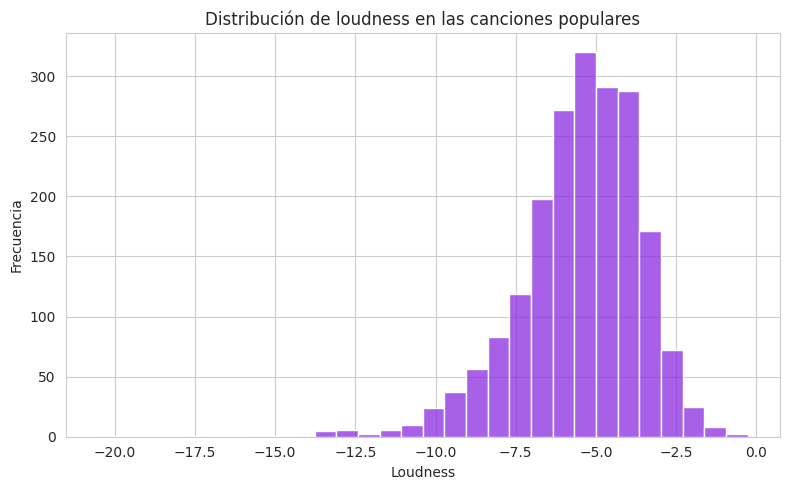

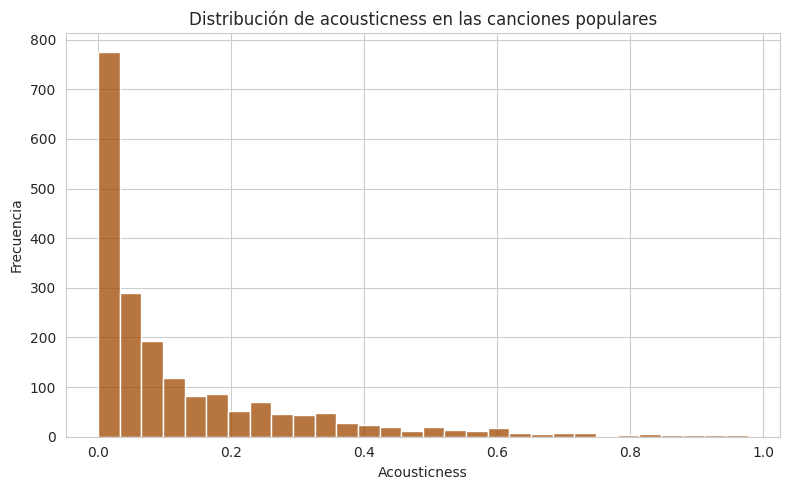

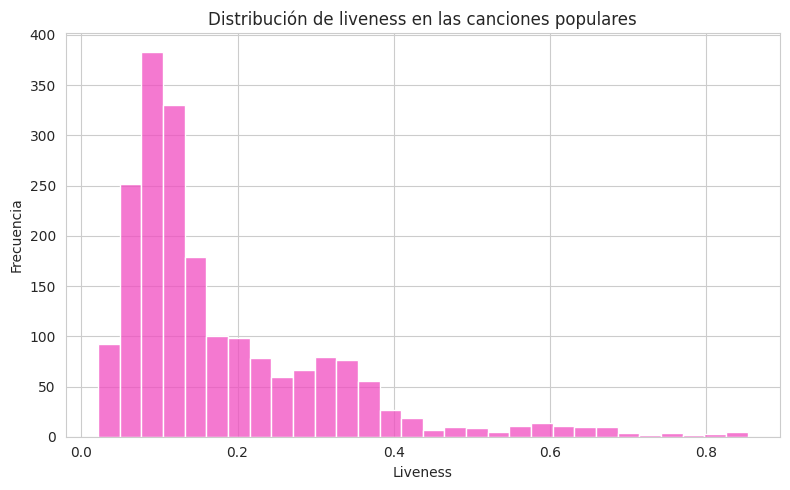

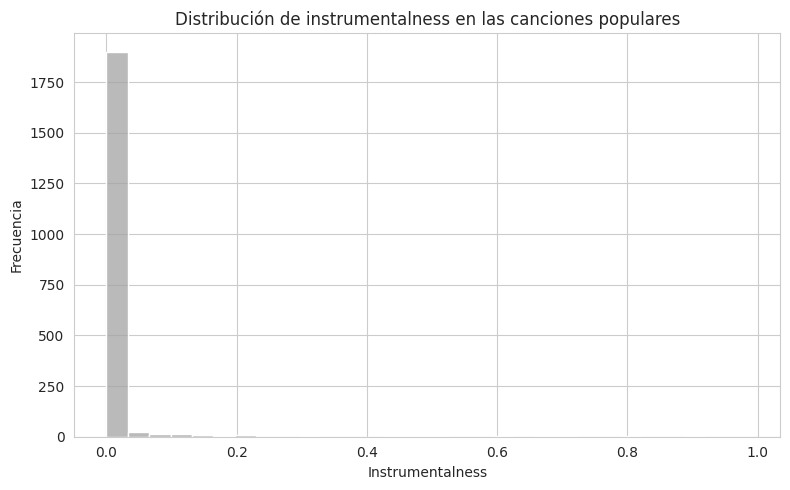

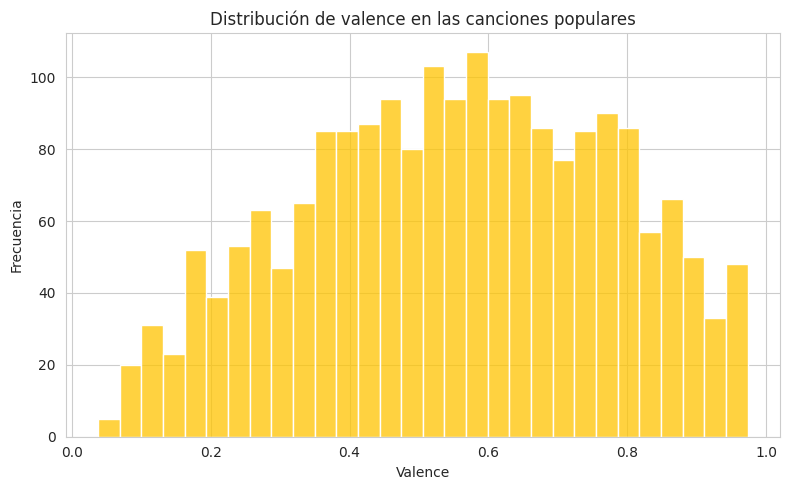

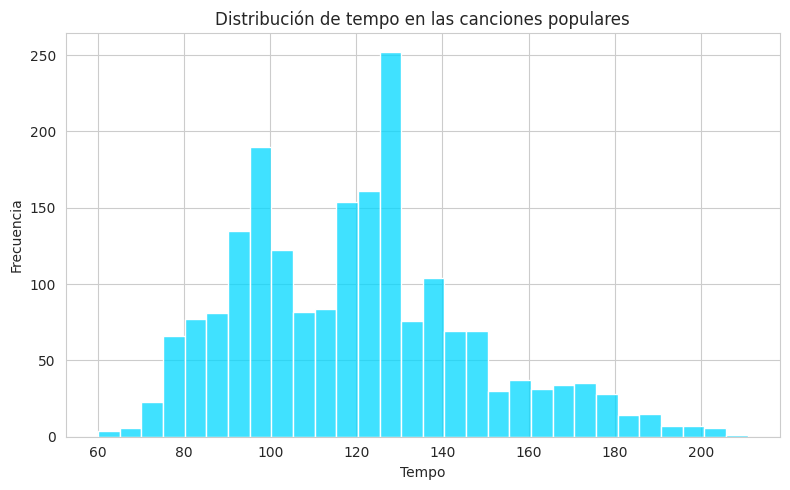

In [45]:
histogram_labels = [
    'popularity', 'danceability', 'energy', 'speechiness',
    'loudness', 'acousticness', 'liveness', 'instrumentalness',
    'valence', 'tempo'
]

colors = sns.color_palette('bright', len(histogram_labels))

for i, feature in enumerate(histogram_labels):

    plt.figure(figsize=(8, 5))

    ax = sns.histplot(
        data=df,
        x=feature,
        color=colors[i],
        bins=30
    )

    ax.set_title(
        f'Distribución de {feature} en las canciones populares'
    )
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()


#11. Detección de valores atípicos

In [54]:
# Usamos el método del rango intercuartílico (IQR) para detectar outliers en popularidad
Q1 = df['popularity'].quantile(0.25)
Q3 = df['popularity'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_pop = df[(df['popularity'] < lower_bound) | (df['popularity'] > upper_bound)]
print(f"Outliers en popularidad: {len(outliers_pop)} canciones")

# Mostramos los 10 más extremos (<= 30)
outliers_pop_sorted = outliers_pop.sort_values('popularity', ascending=False)
display(outliers_pop_sorted[['artist', 'song', 'popularity', 'year']].head(10))

Outliers en popularidad: 194 canciones


,artist,song,popularity,year
771,Hinder,Better Than Me,30,2019
194,K-Ci & JoJo,Crazy,30,2019
509,Akon,Bananza (Belly Dancer),28,2004
206,No Doubt,Underneath It All,27,2001
1356,Duke Dumont,Need U (100%) [feat. A*M*E] - Radio Edit,27,2013
245,No Doubt,Hella Good,26,2001
154,Usher,Pop Ya Collar - Radio Edit,26,2016
257,No Doubt,Hey Baby,24,2001
1434,Calvin Harris,Summer,21,2014
531,Akon,Lonely,21,2004


# 12. Boxplots por género

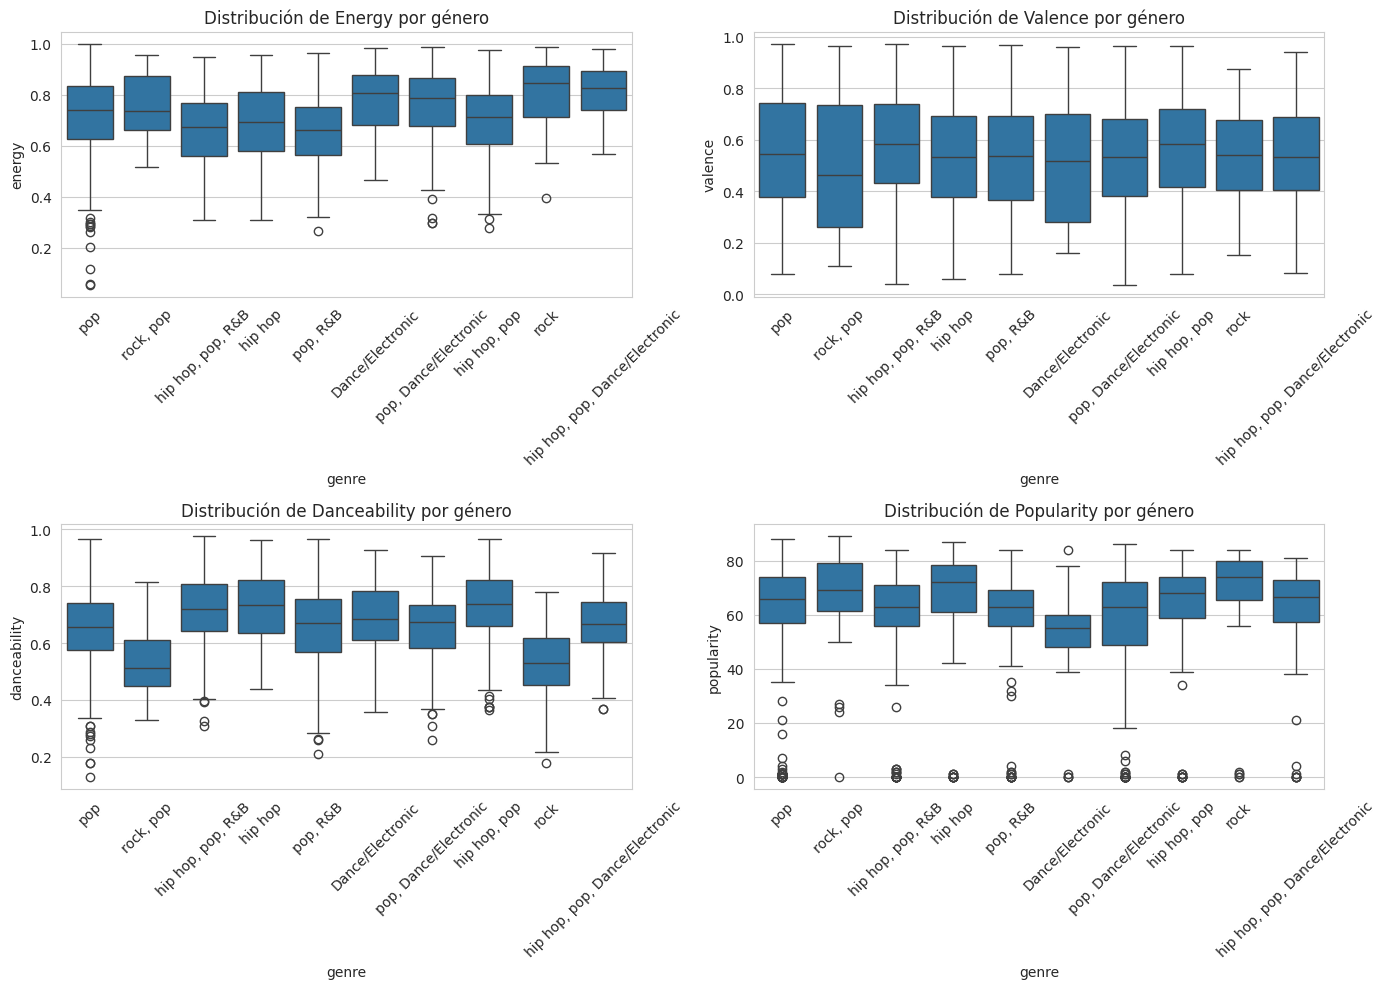

In [50]:
# Seleccionamos los géneros con más de 50 canciones
top_genres = df['genre'].value_counts().head(10).index
df_top_genres = df[df['genre'].isin(top_genres)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = ['energy', 'valence', 'danceability', 'popularity']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df_top_genres, x='genre', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'Distribución de {feature.capitalize()} por género')
    axes[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Problema 1: "El ranking de los más bailables"

Encuentra las 10 canciones más bailables (danceability) del dataset que además tengan una popularidad mayor a 70. Muestra únicamente el artista, el nombre de la canción y su valor de danceability, ordenadas de mayor a menor.


Usa filtrado booleano: df[df['popularity'] > 70]

Ordena con .sort_values(by='danceability', ascending=False)

Selecciona columnas con [['artist', 'song', 'danceability']]

Limita a 10 filas con .head(10)

# Problema 2: "¿Quién domina el dataset?"

Calcula cuántas canciones tiene cada artista en el dataset. Luego, responde:

¿Cuál es el top 5 de artistas con más canciones?

¿Cuál es la popularidad promedio de cada uno de esos 5 artistas?

¿Cuál de ellos tiene la popularidad promedio más alta?



Usa df['artist'].value_counts() para el conteo.

Usa df.groupby('artist')['popularity'].mean() para el promedio.

Combina ambos resultados con .loc[] o fusiona DataFrames.

# Problema 3: "¿La tristeza vende?"

Investiga la relación entre valencia (positividad) y popularidad:

Calcula el coeficiente de correlación de Pearson entre valence y popularity.

Crea un scatter plot con valence en el eje X y popularity en el eje Y.

Responde: ¿existe una relación clara? ¿La música más alegre es más popular?

Usa df['valence'].corr(df['popularity'])

Con Plotly: px.scatter(df, x='valence', y='popularity')

Interpreta: valores cercanos a 0 = sin relación, cercanos a 1 o -1 = relación fuerte.

In [ ]:

# Correlación


# Scatter plot con Matplotlib
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df['valence'],
    df['popularity'],
    c=df['popularity'],
    cmap='RdYlGn',
    alpha=0.5
)

plt.colorbar(scatter, label='Popularidad')
plt.title('Relación entre valencia y popularidad')
plt.xlabel('Valencia (positividad)')
plt.ylabel('Popularidad')

plt.show()

# Problema 4: "El detector de éxitos"

Vamos a construir una "regla sencilla" para detectar posibles éxitos musicales:

Una canción se considera un "hit" si cumple al menos 3 de estas 4 condiciones:

danceability > 0.65

energy > 0.7

valence > 0.5

tempo entre 100 y 130 BPM

Tareas:

Crea una columna num_condiciones con la suma de condiciones cumplidas.

Crea una columna hit que sea True si num_condiciones >= 3.

Calcula la popularidad promedio de los "hits" y de los "no hits".

Responde: ¿la regla funciona? ¿Los "hits" son más populares en promedio?


Suma condiciones booleanas directamente: (df['danceability'] > 0.65).astype(int) + ...

Usa .mean() para comparar popularidades entre grupos.



In [ ]:
import matplotlib.pyplot as plt

# Crear las condiciones


# Sumar condiciones


# Comparar popularidades


# Boxplot con Matplotlib
plt.figure(figsize=(8, 6))

df.boxplot(
    column='popularity',
    by='hit',
    grid=False
)

plt.title('Popularidad de "hits" vs. "no hits" según nuestra regla')
plt.suptitle('')  # Elimina el título automático de Pandas
plt.xlabel('¿Es hit según la regla?')
plt.ylabel('Popularidad')

plt.show()